# Here we test the functionality to check the transformation between behavioral data and EEG grid

In [1]:
from metamers.behavioral.plotting import load_behavior_table
from metamers.EEGbeh.grid_mapping import *
from metamers.eeg.ssvep_plotting import *
import matplotlib.pyplot as plt


# 1. load and select the group of participants for CTR
beh = load_behavior_table()
df_CTR = beh[beh["PartType"] == 1]

# 2. Load the EEG metadata
npz_root = "/home/zevaz/projects/metamers/eeg/ssveps"
df_meta = load_metadata(npz_root)

# 3. Convert behavioral points → grid matrix
points = df_CTR[["Red", "Green"]].to_numpy()
_, B = closest_grid_indices(points)
# 4. Load EEG group map
ECTR, _ = compute_group_mean_map(df_meta, "CTR",normalize=True)

print(ECTR)

[[1.03602766 0.97468148 0.94543095 0.90059666 0.90794203 0.86878174
  0.79890465 0.78357095 0.77636982 0.78800226]
 [0.96700462 0.97859081 0.80756465 0.8275052  0.80866502 0.77570449
  0.78440746 0.72894826 0.76673508 0.79586724]
 [1.03460316 0.89496581 0.8032215  0.61887983 0.51972106 0.60374572
  0.63123607 0.69518771 0.7028088  0.76247075]
 [1.07535454 0.99436563 0.7124993  0.67109304 0.49266456 0.2869788
  0.43891008 0.53349197 0.61762946 0.69861069]
 [1.0590682  0.96557078 0.85654004 0.65485278 0.4523884  0.3113418
  0.26776422 0.4606108  0.57504418 0.62300645]
 [0.99461715 0.9348663  0.73778837 0.72737807 0.54869489 0.4607821
  0.38723258 0.38619718 0.46810269 0.60768922]
 [0.9250507  0.84297788 0.82133269 0.63642392 0.61264133 0.55269778
  0.49687416 0.46014869 0.47343333 0.48839056]
 [0.89056289 0.82184009 0.69227114 0.73321418 0.60182173 0.5996935
  0.58986751 0.54445024 0.53253807 0.5309019 ]
 [0.85463654 0.76784899 0.81095208 0.61949943 0.65342604 0.5800231
  0.57120129 0.64

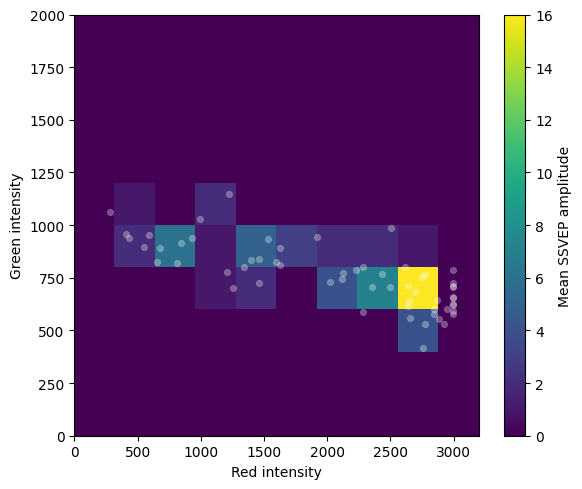

In [ ]:
RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])
cmap="viridis"

plt.figure(figsize=(6, 5))

# Heatmap with optional color scale control
plt.imshow(
    B,
    origin="lower",
    cmap=cmap,
    extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
    aspect="auto"
)
plt.colorbar(label="Mean SSVEP amplitude")

# Overlay scatter points
plt.scatter(
    df_CTR["Red"],
    df_CTR["Green"],
    c="#FFFFFF",
    s=20,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.3
)
plt.xlabel("Red intensity")
plt.ylabel("Green intensity")
plt.tight_layout()
plt.show()

In [2]:
RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])
cmap = "viridis"

def plot_behavior_and_eeg(B, E, df_beh, vmin=None, vmax=None):
    """
    Left: behavioral occupancy matrix B + scatter
    Right: EEG map E
    Both use the same RED/GREEN axes.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # LEFT PANEL — Behavioral
    # -------------------------
    ax = axes[0]
    im1 = ax.imshow(
        B,
        origin="lower",
        cmap=cmap,
        extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        df_beh["Red"],
        df_beh["Green"],
        c="#FFFFFF",
        s=20,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.3
    )

    ax.set_title("Behavioral occupancy")
    ax.set_xlabel("Red intensity")
    ax.set_ylabel("Green intensity")

    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    # -------------------------
    # RIGHT PANEL — EEG
    # -------------------------
    ax = axes[1]
    im2 = ax.imshow(
        E,
        origin="lower",
        cmap=cmap,
        extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title("EEG map")
    ax.set_xlabel("Red intensity")
    ax.set_ylabel("Green intensity")

    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


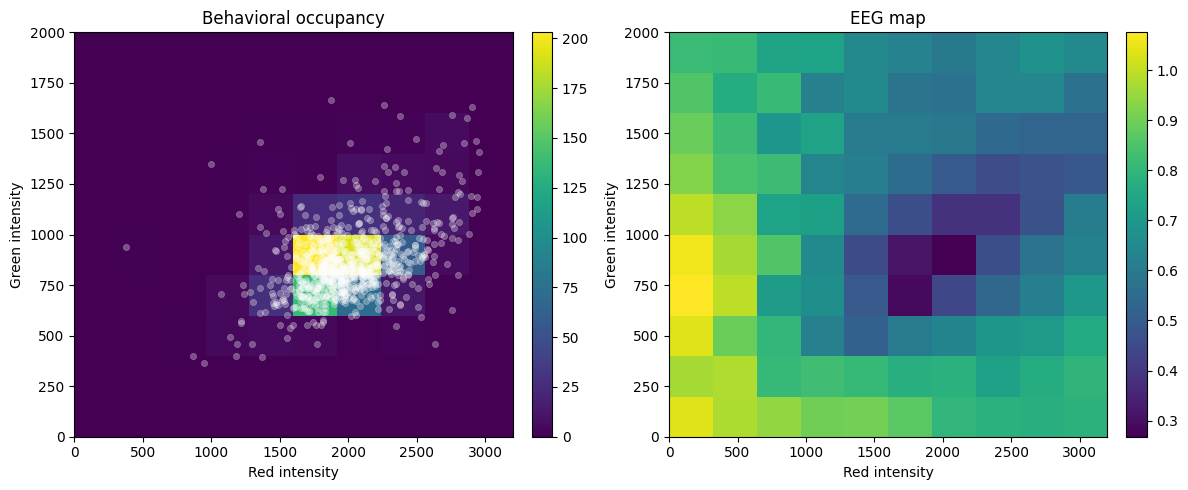

p = 0.0086
obs = 0.3611186790408344


In [3]:
# B = behavioral occupancy matrix (10×10)
# ECTR = EEG map for CTR group (10×10)

plot_behavior_and_eeg(
    B,
    ECTR,
    df_CTR,
)

p, obs, null = permWeighted2Dshifts(B, ECTR, nPerm=5000)

print("p =", p)
print("obs =", obs)


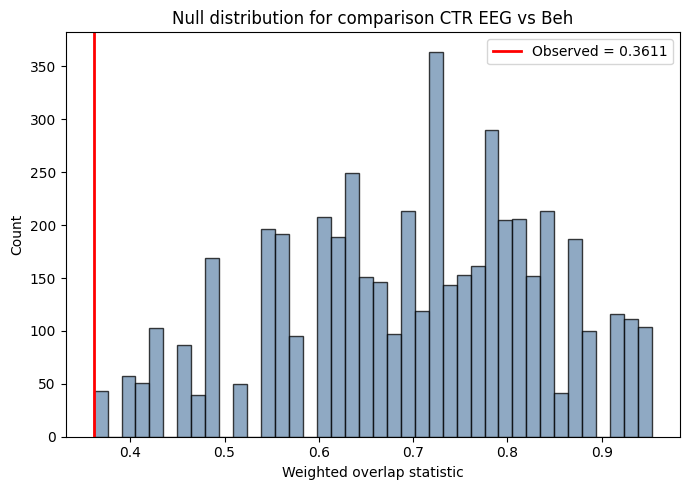

In [4]:
plt.figure(figsize=(7, 5))

# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title("Null distribution for comparison CTR EEG vs Beh")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()